# Lecture 04 — GPA estimator

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Regression · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Predict a numeric GPA from synthetic study-related inputs and examine prediction errors.

## Practical problem
Estimate final GPA (0–4) for a fictional cohort; discuss why prediction is not a substitute for academic grading.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** GPA is clipped to [0,4] and generated from a constructed formula, so real-world drivers are intentionally simplified.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 680 rows × 5 columns


,study_hours_week,attendance_percent,assignment_score,previous_gpa,final_gpa
0,10.6,67.4,72.1,2.93,2.26
1,1.9,85.4,92.8,1.47,2.14
2,6.7,54.9,52.2,3.07,2.06
3,8.2,60.3,44.8,3.18,2.36
4,5.6,85.0,65.7,2.53,1.93


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['study_hours_week', 'attendance_percent', 'assignment_score', 'previous_gpa', 'final_gpa']
Missing values per column:
study_hours_week      0
attendance_percent    0
assignment_score      0
previous_gpa          0
final_gpa             0


## 2. Visualise the target and input–output relationship
For regression the output is **a number**. Study the scatterplot and target distribution before selecting a model.

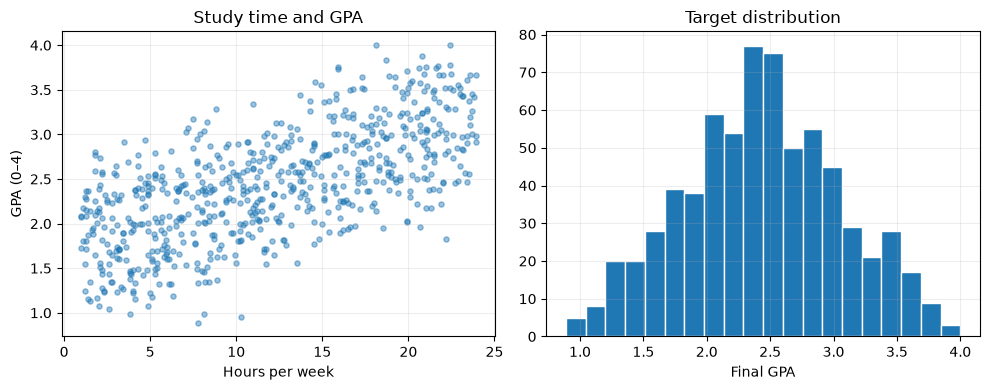

In [3]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].scatter(df['study_hours_week'],df['final_gpa'],s=14,alpha=.45)
ax[0].set(xlabel='Hours per week',ylabel='GPA (0–4)',title='Study time and GPA')
ax[1].hist(df['final_gpa'],bins=20,edgecolor='white');ax[1].set(xlabel='Final GPA',title='Target distribution');plt.tight_layout();plt.show()

## 3. Split the data and fit the chosen regression model
Fit on training data only. The test set estimates how predictions may behave on new examples.

In [4]:
from sklearn.model_selection import train_test_split
X=df[['study_hours_week', 'attendance_percent', 'assignment_score', 'previous_gpa']]
y=df['final_gpa']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=42)
print('Training rows:',len(X_train),'Test rows:',len(X_test))

Training rows: 510 Test rows: 170


### Algorithm choice
**Ridge regression** is a regularised linear regression model. It gives an interpretable numerical baseline and reduces extreme fitted coefficients.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
model=make_pipeline(StandardScaler(),Ridge(alpha=2.0))
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['study_hours_week','attendance_percent','assignment_score','previous_gpa']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


## 4. Evaluate: MAE, RMSE and R²
**MAE** gives typical absolute error in the target’s units; **RMSE** penalises larger errors; **R²** compares prediction quality against predicting the mean. **Accuracy, precision, recall and a confusion matrix are not defined for continuous regression outputs** unless you introduce artificial categories, which would change the task.

MAE (GPA points): 0.175
RMSE (GPA points): 0.218
R²: 0.881


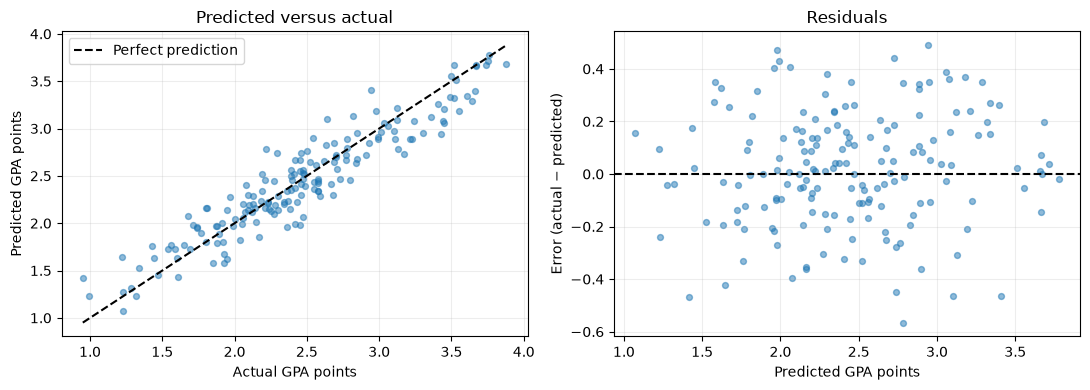

In [6]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
pred=model.predict(X_test)
print('MAE (GPA points):',round(mean_absolute_error(y_test,pred),3))
print('RMSE (GPA points):',round(np.sqrt(mean_squared_error(y_test,pred)),3))
print('R²:',round(r2_score(y_test,pred),3))
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].scatter(y_test,pred,alpha=.5,s=18)
limits=[min(y_test.min(),pred.min()),max(y_test.max(),pred.max())]
ax[0].plot(limits,limits,'k--',label='Perfect prediction');ax[0].legend()
ax[0].set(xlabel='Actual GPA points',ylabel='Predicted GPA points',title='Predicted versus actual')
ax[1].scatter(pred,y_test-pred,s=18,alpha=.5);ax[1].axhline(0,color='k',linestyle='--')
ax[1].set(xlabel='Predicted GPA points',ylabel='Error (actual − predicted)',title='Residuals')
plt.tight_layout();plt.show()

## 5. Use the trained model on new inputs
Predictions are meaningful only within the data-generating range; extreme inputs involve extrapolation and are unreliable.

In [7]:
students=pd.DataFrame([{'study_hours_week':15,'attendance_percent':91,'assignment_score':85,'previous_gpa':3.2},{'study_hours_week':4,'attendance_percent':60,'assignment_score':52,'previous_gpa':2.1}])
students['estimated_gpa']=np.clip(model.predict(students),0,4).round(2)
display(students)

,study_hours_week,attendance_percent,assignment_score,previous_gpa,estimated_gpa
0,15,91,85,3.2,3.17
1,4,60,52,2.1,1.50


## Student investigation and discussion
1. Why is GPA regression rather than classification?
2. What MAE would be acceptable for a purely illustrative estimator?
3. Which feature might be unfairly interpreted as causal?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.